# Homework6: Denoising Diffusion generative models

## Task 1: Theory (4pt)

### Problem 1: KFP theorem (2pt)

In Lecture 10 we have faced with 2 different formulations of Kolmogorov-Fokker-Planck theorem.

1) We used the following KFP theorem when we discussed continuous-in-time NF:
$$
\frac{d \log p(\mathbf{x}(t), t)}{d t} = - \text{tr} \left( \frac{\partial f(\mathbf{x}, t)}{\partial \mathbf{x}} \right).
$$

2) We used the following KFP theorem when we discussed SDEs:
$$
\frac{\partial p(\mathbf{x}, t)}{\partial t} = \text{tr}\left(- \frac{\partial}{\partial \mathbf{x}} \bigl[ \mathbf{f}(\mathbf{x}, t) p(\mathbf{x}, t)\bigr] + \frac{1}{2} g^2(t) \frac{\partial^2 p(\mathbf{x}, t)}{\partial \mathbf{x}^2} \right)
$$

In this task your goal is to prove that the first formulation is a special case of the more general second formulation.

You have to use two facts:
1) Continuous-in-time NF use ODE (not SDE).
2) The derivation in the first formulation is total derivative (not partial).

```
your solution
```

### Problem 2: Faster sampling with DDPM (spaced diffusion) (2pt)

Sampling from DDPM is very slow. In the practical part of HW you will see that it took about 8 seconds to generate a batch of images with our diffusion model (even using a gpu).
While, as you might remember, it took less than a second using other generative models (VAE/GAN/NF).
This drawback can't be solved generally with using more gpus, since it requires iterative sampling.
There are several techniques to alleviate this drawback. In this task We are going to investigate one of them.

Assume we have already trained a model $p(\mathbf{x}_{t - 1} | \mathbf{x}_t, \boldsymbol{\theta})$ to "reverse" a Markov chain of length $T$.

Let try to build inference process using subsequence of timesteps
$\{S_0 = 0, S_1, \ldots, S_{T'-1}, S_{T'} = T\}$, where $T' < T$.

Using this subsequence we have to do $T' (< T)$ inference steps instead of $T$. It could dramatically reduce inference time.

Diffusion models inference are essentially defined by
- schedule of variances $\{\beta_1, \ldots, \beta_T\}$
- reverse process:
$$
p(\mathbf{x}_{S_{t - 1}} | \mathbf{x}_{S_t}, \boldsymbol{\theta}) = \mathcal{N} \bigl(\mathbf{x}_{S_{t - 1}} | \boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{x}_{S_t}, S_t), \tilde{\beta}_{S_t}\bigr)
$$

Therefore, all you have to find is the variances for the new Markov chain: $\{\tilde{\beta}_{S_1}, \ldots, \tilde{\beta}_{S_{T'}}\}$.

**Task:** find the expression for $\tilde{\beta}_{S_t}$ (it should depend on $\alpha$).

```
your solution
```

In [1]:
!pip install --upgrade --no-cache-dir gdown

REPO_NAME = "2023-DGM-MIPT-course"
!if [ -d {REPO_NAME} ]; then rm -Rf {REPO_NAME}; fi
!git clone https://github.com/r-isachenko/{REPO_NAME}.git
!cd {REPO_NAME}
!pip install ./{REPO_NAME}/homeworks/
!mv ./{REPO_NAME}/homeworks/unet.py ./unet.py
!rm -Rf {REPO_NAME}

Cloning into '2023-DGM-MIPT-course'...
remote: Enumerating objects: 1071, done.
remote: Counting objects: 100% (236/236), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 1071 (delta 146), reused 212 (delta 131), pack-reused 835 (from 1)
Receiving objects: 100% (1071/1071), 404.46 MiB | 15.47 MiB/s, done.
Resolving deltas: 100% (429/429), done.
Updating files: 100% (353/353), done.
Processing ./2023-DGM-MIPT-course/homeworks
  Preparing metadata (setup.py) ... done
  Created wheel for dgm_utils: filename=dgm_utils-0.1.0-py3-none-any.whl size=4124 sha256=0fe9466725055f43b778ebb5bcada1e067c9df13d6d3bc87c509c3684bb41d97
  Stored in directory: /tmp/pip-ephem-wheel-cache-977ymdmd/wheels/99/0b/9e/1b4f6487d5299e9cb8b00d0d66e84e5698996debc08c5b3523
Successfully built dgm_utils
  Attempting uninstall: dgm_utils
    Found existing installation: dgm_utils 0.1.0
    Uninstalling dgm_utils-0.1.0:
      Successfully uninstalled dgm_utils-0.1.0


In [2]:
from dgm_utils import visualize_2d_data, visualize_2d_samples, visualize_images, show_samples, load_dataset

In [3]:
from tqdm import tqdm
from typing import List, Tuple
from copy import deepcopy
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

USE_CUDA = torch.cuda.is_available()

## Task 2: DDPM for 2D data (5 pts)

In this part you have to implement your own diffusion model (DDPM) and apply it to 2D dataset.

Let's take a look at dataset samples.

In [4]:
def generate_moons_data(count: int) -> tuple:
    data, labels = make_moons(n_samples=count, noise=0.1)
    data = data.astype("float32")
    split = int(0.8 * count)
    train_data, test_data = data[:split], data[split:]
    train_labels, test_labels = labels[:split], labels[split:]
    return train_data, train_labels, test_data, test_labels

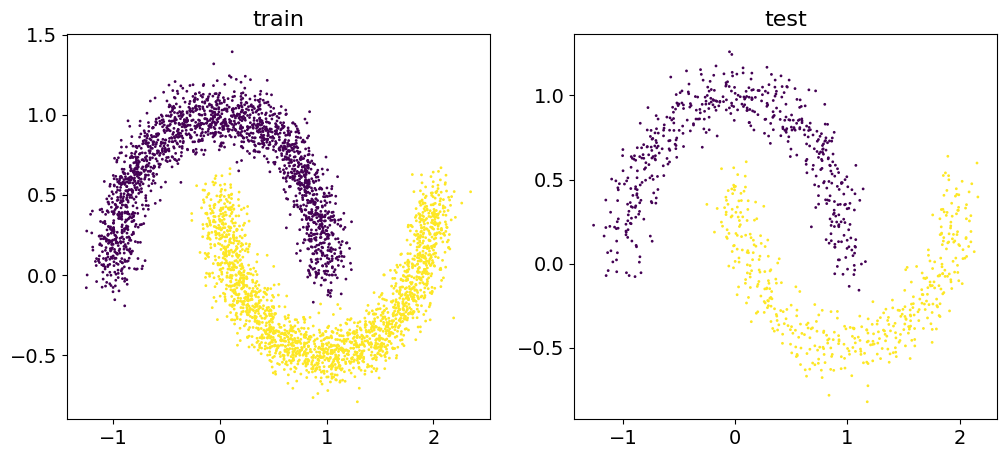

In [5]:
COUNT = 5000

train_data, train_labels, test_data, test_labels = generate_moons_data(COUNT)
visualize_2d_data(train_data, test_data, train_labels, test_labels)

Below you see the utility function, which broadcasts tensors. Look carefully at this code, we will use it in the majority of methods.

In [6]:
def _extract_into_tensor(arr, indices, broadcast_shape):
    """
    Extract values from a 1-D torch tensor for a batch of indices.
    :param arr: 1-D torch tensor.
    :param timesteps: a tensor of indices to extract from arr.
    :param broadcast_shape: a larger shape of K dimensions with the batch
                            dimension equal to the length of timesteps.
    :return: a tensor of shape [batch_size, 1, ...] where the shape has K dims.
    """
    assert len(arr.shape) == 1
    res = arr.to(device=indices.device)[indices].float()
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]


    return res.expand(broadcast_shape)

### Forward Diffusion

Let start with forward diffusion.

**Forward process** is defined as a posterior distribution $q(\mathbf{x}_{1:T}|\mathbf{x}_0)$.

It is a Markov chain, which consequently adds gaussian noise to a given object $\mathbf{x}_0$.

At every step of this process the gaussian noise is added with different magnitude, which is determined with a schedule of variances $\{\beta_1, ... \beta_T\}$.
If this schedule is chosen properly and T goes to infinity (or is large enough), we will converge to pure noise $\mathcal{N}(0, I)$.

Markov chain is defined by:
$$
 q(\mathbf{x}_t | \mathbf{x}_{t - 1}) := \mathcal{N}(\mathbf{x}_t | \sqrt{1 - \beta_t}x_{t - 1}, \beta_tI), \ \ \ \ \ \ \ q(\mathbf{x}_{1:T}|\mathbf{x}_0) = \prod_{t = 1}^T q(\mathbf{x}_t | \mathbf{x}_{t - 1})
$$

In order to get $\mathbf{x}_t$ we have to compute $\mathbf{x}_1, ..., \mathbf{x}_{t - 1}$ iteratively.

Hopefully, due to the properties of the gaussian distribution we can do it more efficiently.

Let's denote
$\alpha_t = 1- \beta_t$ и $\bar{\alpha}_t= \prod_{s = 1}^t\alpha_s$.
Then
$$
q(\mathbf{x}_t | \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_t|\sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1-\bar{\alpha}_t) \mathbf{I}).
\tag{1}
$$

Here we could get very useful expression
$$
    \mathbf{x}_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t} \cdot \boldsymbol{\epsilon}. \tag{2}
$$

Now we will create base class for diffusion (we will use it as a python base class for forward and backward diffusions).

In [87]:
class BaseDiffusion:
    def __init__(self, num_timesteps: int, device="cuda"):
        self.num_timesteps = num_timesteps
        self.betas = self._get_beta_schedule(num_timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=-1)
        self.alphas_cumprod = torch.clamp(self.alphas_cumprod, min=1e-8, max=1.0-1e-8)

        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_cumprod = self.alphas_cumprod.to(device)

    @staticmethod
    def _get_beta_schedule(num_diffusion_timesteps):
        assert num_diffusion_timesteps >= 20
        scale = 1000 / num_diffusion_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        betas = np.linspace(beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64)
        assert len(betas.shape) == 1, "betas must be 1-D"
        assert (betas > 0).all() and (betas <= 1).all()
        betas = torch.from_numpy(betas).double()
        return betas

basediff = BaseDiffusion(num_timesteps=20)
basediff.betas

tensor([0.0050, 0.0574, 0.1097, 0.1621, 0.2145, 0.2668, 0.3192, 0.3716, 0.4239,
        0.4763, 0.5287, 0.5811, 0.6334, 0.6858, 0.7382, 0.7905, 0.8429, 0.8953,
        0.9476, 1.0000], device='cuda:0', dtype=torch.float64)

We are ready to define forward diffusion process. It has 2 methods:
- to get mean and variance of the distribution $q(\mathbf{x}_t | \mathbf{x}_0)$,
- to get samples from this distribution.

In [91]:
class ForwardDiffusion(BaseDiffusion):
    def get_mean_variance(self, x0, t):
        # ====
        # your code
        # calculate mean and variance of the distribution q(x_t | x_0) (use equation (1))
        sqrt_alphas_cumprod = self.alphas_cumprod.sqrt()
        mean = sqrt_alphas_cumprod[t].float() * x0
        variance = (1 - self.alphas_cumprod[t]).float() * torch.ones_like(x0)
        # ====
        return mean, variance

    def get_samples(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        # ====
        # your code
        # sample from the distribution q(x_t | x_0) (use equation (2))
        samples = self.alphas_cumprod[t].sqrt().float() * x0 + (1 - self.alphas_cumprod[t]).sqrt().float() * noise
        # ====
        return samples


def test_forward_diffusion():
    fdiff = ForwardDiffusion(num_timesteps=100, device="cpu")
    SHAPE = [2, 20]
    x0 = torch.ones(SHAPE)
    t = torch.ones((2, 1)).long() * 5
    mean, variance = fdiff.get_mean_variance(x0=x0, t=t)
    assert list(mean.shape) == SHAPE
    assert list(variance.shape) == SHAPE
    assert np.allclose(mean.numpy(), np.ones(SHAPE) * 0.9820154)
    assert np.allclose(variance.numpy(), np.ones(SHAPE) * 0.03564582)

    xt = fdiff.get_samples(x0=x0, t=t)
    assert list(xt.shape) == SHAPE

    noise = torch.ones(SHAPE)
    xt = fdiff.get_samples(x0=x0, t=t, noise=noise)
    assert np.allclose(xt.numpy(), np.ones(SHAPE) * 1.1708164)


test_forward_diffusion()

Let visualize the forward diffusion process. Here you have to see how the distribution of the real samples transforms to the gaussian noise.

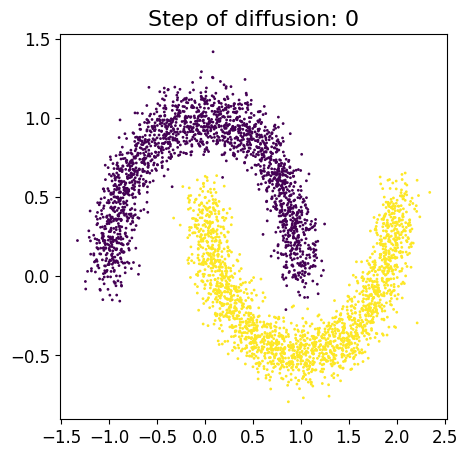

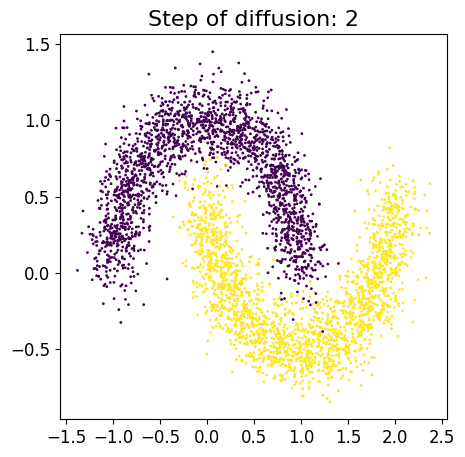

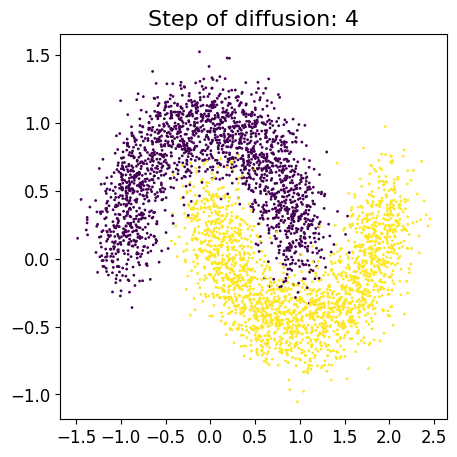

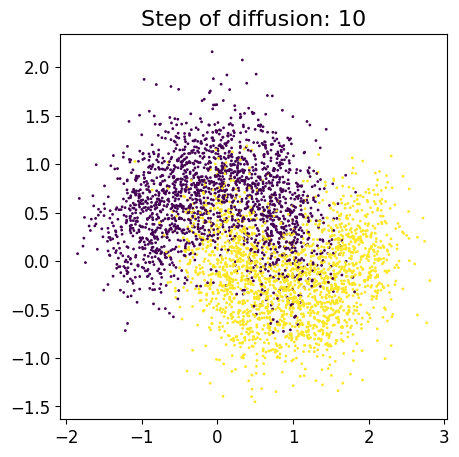

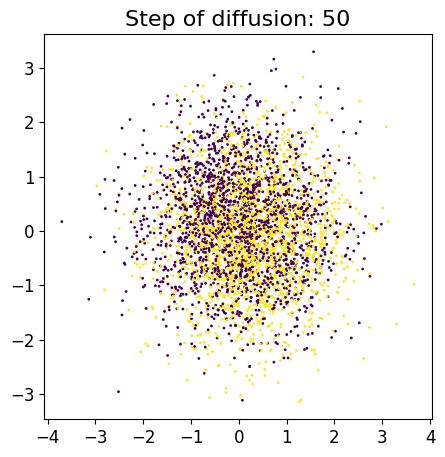

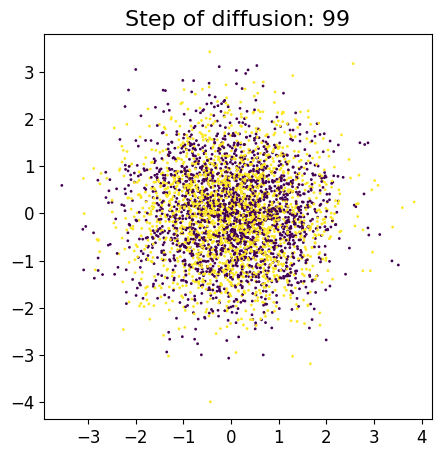

In [9]:
T = 100

fdiff = ForwardDiffusion(num_timesteps=T, device="cpu")

timestamps=[0, 2, 4, 10, 50, 99]

plot_n_steps = len(timestamps)
for i, t in enumerate(timestamps):
    x = fdiff.get_samples(x0=torch.from_numpy(train_data), t=torch.ones((train_data.shape[0], 1)).long() * t)
    visualize_2d_samples(x, title=f"Step of diffusion: {t}", labels=train_labels)

### Reverse Diffusion

**Reverse process** consequently denoises pure gaussian noise $\mathcal{N}(0, \mathbf{I})$ until we do not get the object from the original distribution $\pi(\mathbf{x})$.

It is a probability model with latent variables
$p(\mathbf{x}_0 | \boldsymbol{\theta}) := \int p(\mathbf{x}_{0:T} | \boldsymbol{\theta}) d\mathbf{x}_{1:T}$,
where
- latents $\mathbf{z} = \{\mathbf{x}_1, ..., \mathbf{x}_T \}$ correspond to noised objects
- $\mathbf{x}_0$ is an object from the original distribution $\pi(\mathbf{x})$.

Joint distribution $p(\mathbf{x}_{0:T} | \boldsymbol{\theta})$ is called reverse diffusion process, which is essentially a Markov chain of gaussian distributions $p(\mathbf{x}_{i-1}|\mathbf{x}_{i}, \boldsymbol{\theta})$:
$$
p(\mathbf{x}_{0:T}) = p(\mathbf{x}_T) \prod_{t = 1}^T p(\mathbf{x}_{t-1}|\mathbf{x}_t, \boldsymbol{\theta}), \quad p(\mathbf{x}_{T} | \boldsymbol{\theta})=\mathcal{N}(\mathbf{x}_T | 0, \mathbf{I})
$$
$$
  p(\mathbf{x}_{t - 1}|\mathbf{x}_t | \boldsymbol{\theta}) = \mathcal{N}(\mathbf{x}_{t - 1}| \boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{x}_t, t), \boldsymbol{\sigma}^2_{\boldsymbol{\theta}}(\mathbf{x}_t, t)). \tag{3}
$$

In Lecture 12 we have derived ELBO for this model:

$$
    \mathcal{L}(q, \boldsymbol{\theta}) =  \mathbb{E}_{q} \Bigl[\log p(\mathbf{x}_0 | \mathbf{x}_1, \boldsymbol{\theta}) - KL\bigl(q(\mathbf{x}_T | \mathbf{x}_0) || p(\mathbf{x}_T)\bigr)
    - \sum_{t=2}^T \underbrace{KL \bigl(q(\mathbf{x}_{t-1} | \mathbf{x}_t, \mathbf{x}_0) || p(\mathbf{x}_{t - 1} | \mathbf{x}_t, \boldsymbol{\theta} )\bigr)}_{\mathcal{L}_t} \Bigr].
$$

Here we use the following distribution $q(\mathbf{x}_{t-1} | \mathbf{x}_t, \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_{t-1}; \boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0), \tilde{\beta}_t \mathbf{I}) $, where
$$
\boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0) = \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \mathbf{x}_t + \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1 - \bar{\alpha}_t} \mathbf{x}_0
\tag{4}
$$
$$
\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \cdot \beta_t
\tag{5}
$$

(These scary formulas are not difficult to derive, follow the link to find details [Denoising Diffusion Probabilistic Models (Ho et al. 2020)](https://arxiv.org/abs/2006.11239)).

Now our goal is to define parameters $\boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{x}_t, t), \boldsymbol{\sigma}^2_{\boldsymbol{\theta}}(\mathbf{x}_t, t)$ of reverse diffusion.

#### Variance
Our first assumption is to set the variance $\boldsymbol{\sigma}^2_{\boldsymbol{\theta}}(\mathbf{x}_t, t) = \tilde{\beta}_t$. This is very native assumption

#### Mean
Here we will use the expression (2) to get $\mathbf{x}_0$ from $\mathbf{x}_t$:
$$
    \mathbf{x}_0 = \frac{\mathbf{x}_t - \sqrt{1 - \bar{\alpha}_{t}} \cdot \boldsymbol{\epsilon}}{\sqrt{\bar{\alpha}_{t}}}.
    \tag{6}
$$

If we put this expression to the formula (4) we will get:
$$
    \boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0) = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \cdot \boldsymbol{\epsilon} \right).
$$

So the idea here to parametrize the model mean in the same functional form:
$$
    \boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \cdot \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) \right).
$$

**Note:** our model will predict the noise which was applied to $\mathbf{x}_0$ to get $\mathbf{x}_t$.

In [90]:
class ReverseDiffusion(BaseDiffusion):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=self.betas.device), self.alphas_cumprod[:-1]], dim=0
        )

        # ====
        # your code
        # calculate variance of the distribution q(x_{t-1} | x_t, x_0) mean (use equation (5))
        variance = (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod) * self.betas
        # ====
        # first value is zero, futher we will take log of this expression, so we will replace first value by the second value.
        self.variance_clipped = torch.cat([variance[1:2], variance[1:]], dim=0)

        # ====
        # your code
        # calculate coefficients of the distribution q(x_{t-1} | x_t, x_0) mean (use equation (4))
        self.xt_coef = self.alphas.sqrt() * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)
        self.x0_coef = self.alphas_cumprod_prev.sqrt() * self.betas / (1 - self.alphas_cumprod)
        # ====

    def get_x0(self, xt, eps, t):
        # ====
        # your code
        # get x_0 (use equation (6))
        x0 = (xt - (1 - self.alphas_cumprod[t]).sqrt() * eps) / self.alphas_cumprod[t].sqrt()
        # ====
        x0 = torch.clamp(x0, -1.0, 1.0)
        return x0

    def get_mean_variance(self, xt, eps, t):
        # ====
        # your code
        # get mean and variance of the distribution q(x_{t-1} | x_t, x_0) mean (use equations (4) and (5))
        mean = self.xt_coef[t] * xt + self.x0_coef[t] * self.get_x0(xt=xt, eps=eps, t=t)
        variance = self.variance_clipped[t] * torch.ones_like(xt)
        # ====
        return mean, variance

    def get_samples(self, xt, eps, t):
        # read this code carefully
        mean, variance = self.get_mean_variance(xt=xt, eps=eps, t=t)
        noise = torch.randn_like(xt, device=xt.device)

        nonzero_mask = torch.ones_like(t)  # to not add any noise while predicting x0
        nonzero_mask[t == 0] = 0
        nonzero_mask = _extract_into_tensor(
            nonzero_mask.view(-1), torch.arange(nonzero_mask.shape[0]), xt.shape
        )
        nonzero_mask = nonzero_mask.to(xt.device)
        sample = mean + nonzero_mask * variance.sqrt() * noise

        return sample.float()


def test_reverse_diffusion():
    rdiff = ReverseDiffusion(num_timesteps=100, device="cpu")
    SHAPE = [2, 20]
    xt = torch.ones(SHAPE)
    eps = torch.ones(SHAPE)
    t = torch.ones((2, 1)).long() * 5

    x0 = rdiff.get_x0(xt=xt, eps=eps, t=t)
    assert list(x0.shape) == SHAPE
    assert np.allclose(x0.numpy(), np.ones(SHAPE) * 0.8260552)

    mean, variance = rdiff.get_mean_variance(xt=xt, eps=eps, t=t)
    assert list(mean.shape) == SHAPE
    assert list(variance.shape) == SHAPE
    assert np.allclose(mean.numpy(), np.ones(SHAPE) * 0.9467155)
    assert np.allclose(variance.numpy(), np.ones(SHAPE) * 0.007709955)


    x = rdiff.get_samples(xt, eps, t)
    assert list(x.shape) == SHAPE


test_reverse_diffusion()

### Model

In this task we will use simple MLP model to parametrize distribution $p(\mathbf{x}_{t-1} | \mathbf{x}_t, \boldsymbol{\theta})$. It will be conditioned on the timestamps.

In [11]:
class ConditionalMLP(nn.Module):
    def __init__(self, input_dim: int, num_embeds: int, hidden_dim: int = 128):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.x_proj = nn.Linear(input_dim, self.hidden_dim)
        self.t_proj = nn.Embedding(num_embeds, self.hidden_dim)
        self.backbone = nn.Sequential(
            nn.Linear(self.hidden_dim, 2 * self.hidden_dim),
            nn.GELU(),
            nn.Linear(2 * self.hidden_dim, input_dim),
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x, t):
        x = self.x_proj(x)
        t = self.t_proj(t.int())
        x = x + t
        x = F.gelu(x)
        return self.backbone(x)


def test_conditional_mlp():
    SHAPE = [2, 20]
    T = 100
    x = torch.ones(SHAPE)
    t = torch.ones((2,)).long() * 5
    model = ConditionalMLP(input_dim=20, num_embeds=100)
    output = model(x, t)
    assert list(output.shape) == SHAPE


test_conditional_mlp()

### DDPM

Let return to the ELBO. The main part of it is:
$$
    \mathcal{L}_t = KL \bigl(q(\mathbf{x}_{t-1} | \mathbf{x}_t, \mathbf{x}_0) || p(\mathbf{x}_{t - 1} | \mathbf{x}_t, \boldsymbol{\theta} )\bigr)
$$

In Lecture 12 we have got that
$$
    \mathcal{L}_t = \mathbb{E}_{\boldsymbol{\epsilon}} \left[ \frac{\beta_t^2}{2 \tilde{\beta_t} \alpha_t (1 - \bar{\alpha}_t)} \| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t) \|^2 \right].
$$

In practice this loss is simplified. Particilarly, we will omit coefficient of the norm and we will sample index $t$ at each training step.

Finally, we will train our model with the following objective:
$$
\text{loss} = \mathbb{E}_{\mathbf{x}_0, \boldsymbol{\epsilon}, t}\bigg[ \|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t)\|^2\bigg],
$$
where $\mathbf{x}_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon}$.

The following class implements two methods:
- `train_loss` - to compute the loss at the training step;
- `sample` - to sample from the final model.

In [22]:
class DDPM(nn.Module):
    def __init__(self, num_timesteps: int, model: nn.Module):
        super().__init__()

        self.num_timesteps = num_timesteps

        self.forward_diffusion = ForwardDiffusion(num_timesteps=num_timesteps)
        self.reverse_diffusion = ReverseDiffusion(num_timesteps=num_timesteps)
        self.model = model
        self.shape = None

    @property
    def device(self):
        return next(self.parameters()).device

    def sample(self, num_samples):
        assert self.shape is not None
        x = torch.randn((num_samples, *self.shape), device=self.device, dtype=torch.float32)
        indices = list(range(self.num_timesteps))[::-1]

        for i in tqdm(indices):
            t = torch.tensor([i] * num_samples, device=self.device)
            with torch.no_grad():
                # ====
                # your code
                # 1) get epsilon from the model
                # 2) sample from the reverse diffusion
                eps = self.model(x, t)
                x = self.reverse_diffusion.get_samples(x, eps, t.unsqueeze(1))
                # ====
        return x

    def train_loss(self, x0):
        if self.shape is None:
            self.shape = list(x0.shape)[1:]
        t = torch.randint(0, self.num_timesteps, size=(x0.size(0),), device=self.device)
        noise = torch.randn_like(x0)

        # ====
        # your code
        # 1) get x_t
        # 2) get epsilon from the model
        x_t = self.forward_diffusion.get_samples(x0, t.unsqueeze(1), noise)
        eps = self.model(x_t, t)
        # ====
        loss = F.mse_loss(eps, noise)
        return loss

### Training

Now we are ready to train our model.

In [13]:
def train_model(
    ddpm: DDPM,
    dataloader,
    lr: float,
    weight_decay: float,
    steps: int,
    use_cuda: bool,
    log_every: int = 500
):

    def _anneal_lr(step: int):
        frac_done = step / steps
        current_lr = lr * (1 - frac_done)
        for param_group in optimizer.param_groups:
            param_group["lr"] = current_lr

    if USE_CUDA:
        ddpm = ddpm.cuda()
    optimizer = torch.optim.AdamW(
        ddpm.model.parameters(), lr=lr, weight_decay=weight_decay
    )
    step = 0
    curr_loss_gauss = 0.0
    curr_count = 0
    optimizer.zero_grad()
    data_iter = iter(dataloader)
    while step < steps:
        try:
            x = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            x = next(data_iter)

        if USE_CUDA:
            x = x.cuda()

        loss = ddpm.train_loss(x)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        _anneal_lr(step)

        curr_count += len(x)
        curr_loss_gauss += loss.item() * len(x)

        if (step + 1) % log_every == 0:
            gloss = np.around(curr_loss_gauss / curr_count, 4)
            print(f"Step {(step + 1)}/{steps} Loss: {gloss}")
            curr_count = 0
            curr_loss_gauss = 0.0

        step += 1

In [35]:
T = 100
# ====
# your code
# choose these parameters
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
STEPS = 1e6
# ====

model = ConditionalMLP(input_dim=2, num_embeds=T)
ddpm = DDPM(num_timesteps=T, model=model)

dataloader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

train_model(
    ddpm=ddpm,
    dataloader=dataloader,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    steps=STEPS,
    use_cuda=USE_CUDA
)

Step 500/1000000.0 Loss: 0.2523
Step 1000/1000000.0 Loss: 0.2184
Step 1500/1000000.0 Loss: 0.2179
Step 2000/1000000.0 Loss: 0.2083
Step 2500/1000000.0 Loss: 0.2061
Step 3000/1000000.0 Loss: 0.2046
Step 3500/1000000.0 Loss: 0.2007
Step 4000/1000000.0 Loss: 0.2032
Step 4500/1000000.0 Loss: 0.2036
Step 5000/1000000.0 Loss: 0.2024
Step 5500/1000000.0 Loss: 0.2049
Step 6000/1000000.0 Loss: 0.2019
Step 6500/1000000.0 Loss: 0.1973
Step 7000/1000000.0 Loss: 0.2053
Step 7500/1000000.0 Loss: 0.206
Step 8000/1000000.0 Loss: 0.1987
Step 8500/1000000.0 Loss: 0.1936
Step 9000/1000000.0 Loss: 0.2014
Step 9500/1000000.0 Loss: 0.2007
Step 10000/1000000.0 Loss: 0.202
Step 10500/1000000.0 Loss: 0.192
Step 11000/1000000.0 Loss: 0.2009
Step 11500/1000000.0 Loss: 0.1963
Step 12000/1000000.0 Loss: 0.1889
Step 12500/1000000.0 Loss: 0.1984
Step 13000/1000000.0 Loss: 0.195
Step 13500/1000000.0 Loss: 0.1977
Step 14000/1000000.0 Loss: 0.1954
Step 14500/1000000.0 Loss: 0.1947
Step 15000/1000000.0 Loss: 0.2017
Step

Now let's sample from our trained model.

100%|██████████| 100/100 [00:00<00:00, 617.64it/s]


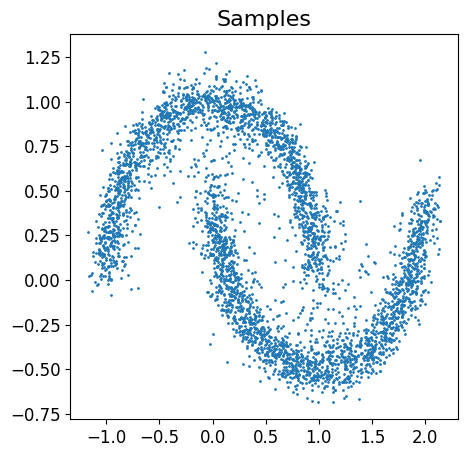

In [36]:
samples = ddpm.sample(num_samples=4000).cpu()

visualize_2d_samples(samples, title="Samples")

Now let's see how denoising looks like (similarly to forward noising process).

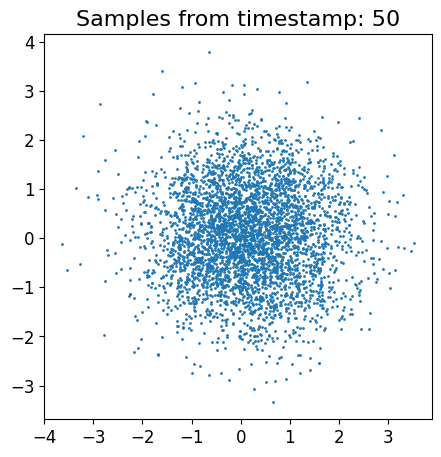

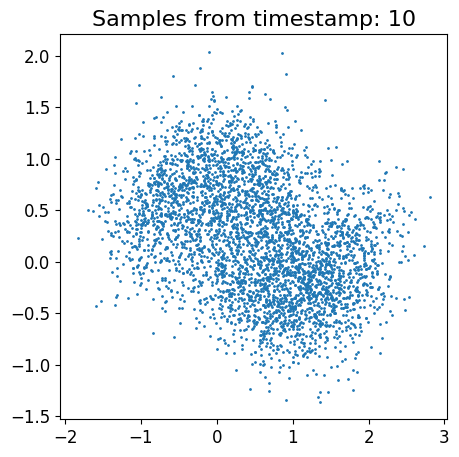

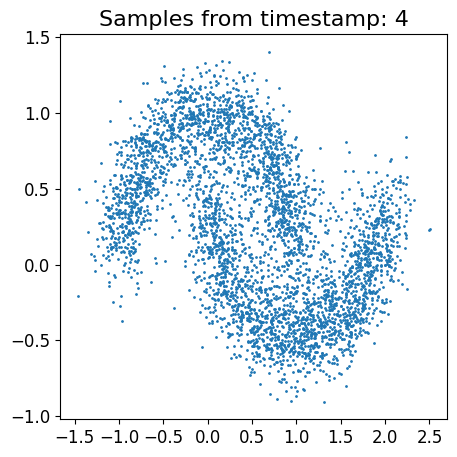

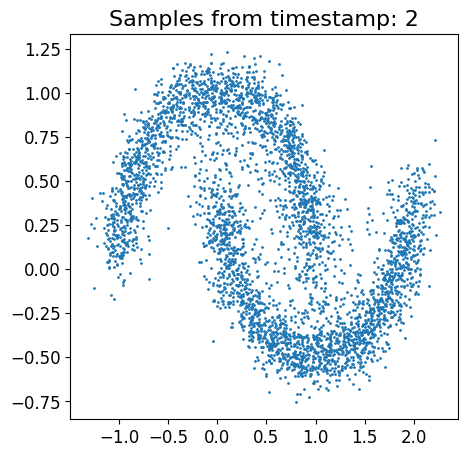

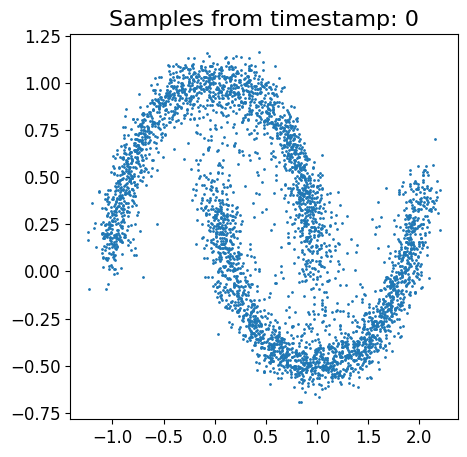

In [37]:
timestamps=[0, 2, 4, 10, 50]

x = torch.randn(train_data.shape[0], 2, requires_grad=False).to(ddpm.device)
for i in range(ddpm.num_timesteps - 1, -1, -1):
    t = torch.tensor(i, dtype=torch.long, requires_grad=False).expand(x.shape[0]).to(ddpm.device)
    with torch.no_grad():
        eps = ddpm.model(x, t)
        x = ddpm.reverse_diffusion.get_samples(xt=x, eps=eps, t=t.unsqueeze(1))
    if i in reversed(timestamps):
        x_ = x.cpu()
        visualize_2d_samples(x_, title=f"Samples from timestamp: {i}")

## Task3: DDPM on MNIST (4pt)

Let apply our diffusion model to the MNIST dataset.

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.16MB/s]


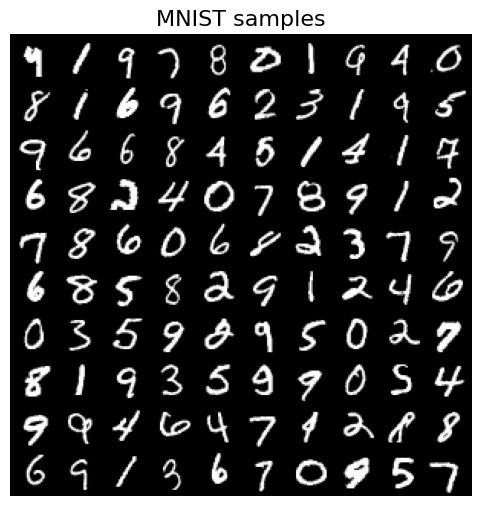

In [38]:
train_data, test_data = load_dataset("mnist", flatten=False, binarize=False)

visualize_images(train_data, "MNIST samples")

DATA_MEAN = train_data.mean()
DATA_STD = train_data.std()

train_data = (train_data - DATA_MEAN) / DATA_STD

Let's take a look at the forward process for the MNIST images.

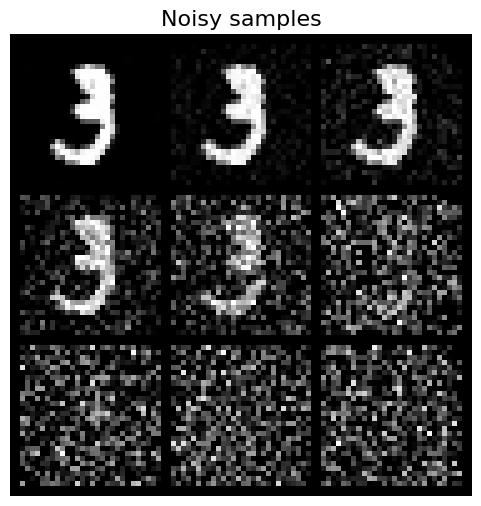

In [40]:
T = 1000

fdiff = ForwardDiffusion(num_timesteps=T, device="cpu")

timestamps=[0, 50, 100, 200, 300, 500, 600, 800, 999]

plot_n_steps = len(timestamps)
samples = []
x0 = train_data[10:11]
for i, t in enumerate(timestamps):
    x = fdiff.get_samples(x0=torch.from_numpy(x0), t=torch.ones((x0.shape[0], 1)).long() * t)
    samples.append(x.cpu().numpy())

samples = np.concatenate(samples)
samples = samples * DATA_STD + DATA_MEAN
show_samples(samples, title="Noisy samples")

The model is written for you. We will use UNet architecture.

In [41]:
from unet import MyUNet

In this task you just have to train the model. All previous parts of the pipeline will be the same.

In [63]:
class DDPM_mnist(nn.Module):
    def __init__(self, num_timesteps: int, model: nn.Module):
        super().__init__()

        self.num_timesteps = num_timesteps

        self.forward_diffusion = ForwardDiffusion(num_timesteps=num_timesteps)
        self.reverse_diffusion = ReverseDiffusion(num_timesteps=num_timesteps)
        self.model = model
        self.shape = None

    @property
    def device(self):
        return next(self.parameters()).device

    def sample(self, num_samples):
        assert self.shape is not None
        x = torch.randn((num_samples, *self.shape), device=self.device, dtype=torch.float32)
        indices = list(range(self.num_timesteps))[::-1]

        for i in tqdm(indices):
            t = torch.tensor([i] * num_samples, device=self.device)
            with torch.no_grad():
                # ====
                # your code
                # 1) get epsilon from the model
                # 2) sample from the reverse diffusion
                eps = self.model(x, t)
                x = self.reverse_diffusion.get_samples(x, eps, t.view(-1, 1, 1, 1))
                # ====
        return x

    def train_loss(self, x0):
        if self.shape is None:
            self.shape = list(x0.shape)[1:]
        t = torch.randint(0, self.num_timesteps, size=(x0.size(0),), device=self.device)
        noise = torch.randn_like(x0)

        # ====
        # your code
        # 1) get x_t
        # 2) get epsilon from the model
        x_t = self.forward_diffusion.get_samples(x0, t.view(-1, 1, 1, 1), noise)
        eps = self.model(x_t, t)
        # ====
        loss = F.mse_loss(eps, noise)
        return loss

In [75]:
def train_model_mnist(
    ddpm: DDPM,
    dataloader,
    lr: float,
    weight_decay: float,
    steps: int,
    use_cuda: bool,
    log_every: int = 500
):

    def _anneal_lr(step: int):
        frac_done = step / steps
        current_lr = lr * (1 - frac_done)
        for param_group in optimizer.param_groups:
            param_group["lr"] = current_lr

    if USE_CUDA:
        ddpm = ddpm.cuda()
    optimizer = torch.optim.AdamW(
        ddpm.model.parameters(), lr=lr, weight_decay=weight_decay
    )
    step = 0
    curr_loss_gauss = 0.0
    curr_count = 0
    optimizer.zero_grad()
    data_iter = iter(dataloader)
    while step < steps:

        try:
            x = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            x = next(data_iter)

        if USE_CUDA:
            x = x.cuda()

        loss = ddpm.train_loss(x)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        _anneal_lr(step)

        curr_count += len(x)
        curr_loss_gauss += loss.item() * len(x)

        if (step + 1) % log_every == 0:
            gloss = np.around(curr_loss_gauss / curr_count, 4)
            print(f"Step {(step + 1)}/{steps} Loss: {gloss}")
            curr_count = 0
            curr_loss_gauss = 0.0

        if (step + 1) % (log_every * 2) == 0:
            with torch.no_grad():
                samples = ddpm.sample(num_samples=4).cpu().numpy()

            show_samples(samples, title="Samples")

        step += 1

Step 1000/100000.0 Loss: 0.3149
Step 2000/100000.0 Loss: 0.0979


100%|██████████| 1000/1000 [00:05<00:00, 169.68it/s]


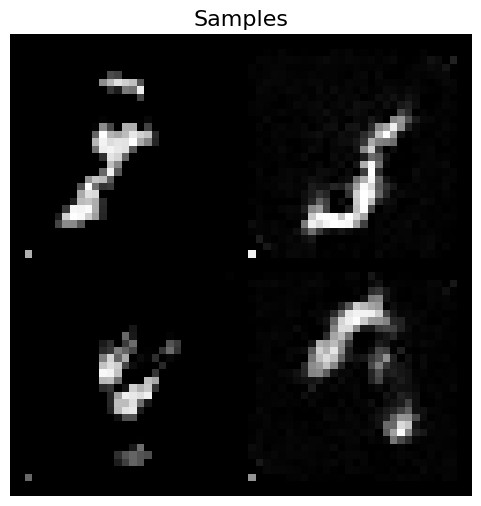

Step 3000/100000.0 Loss: 0.081
Step 4000/100000.0 Loss: 0.0726


100%|██████████| 1000/1000 [00:05<00:00, 169.89it/s]


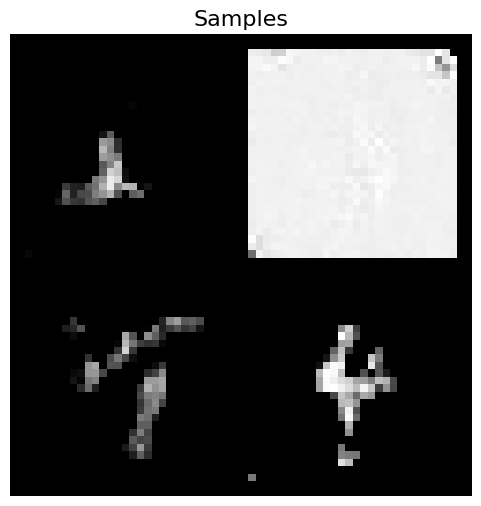

Step 5000/100000.0 Loss: 0.0671
Step 6000/100000.0 Loss: 0.0626


100%|██████████| 1000/1000 [00:06<00:00, 154.79it/s]


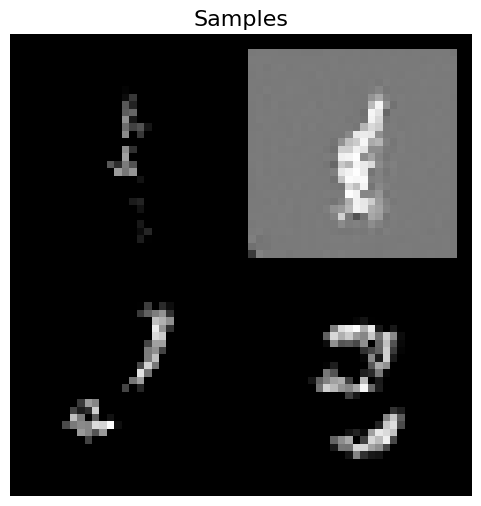

Step 7000/100000.0 Loss: 0.059
Step 8000/100000.0 Loss: 0.0568


100%|██████████| 1000/1000 [00:06<00:00, 153.59it/s]


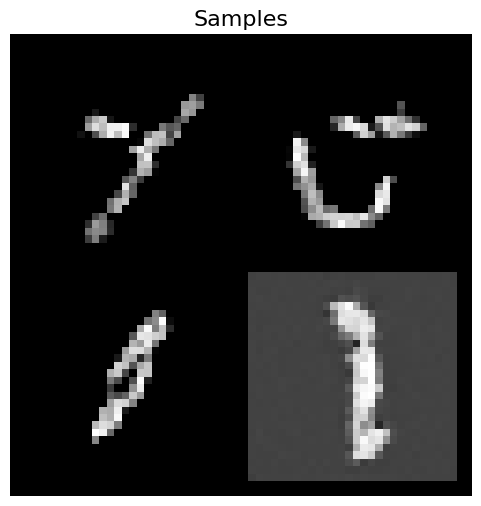

Step 9000/100000.0 Loss: 0.0548
Step 10000/100000.0 Loss: 0.053


100%|██████████| 1000/1000 [00:06<00:00, 162.31it/s]


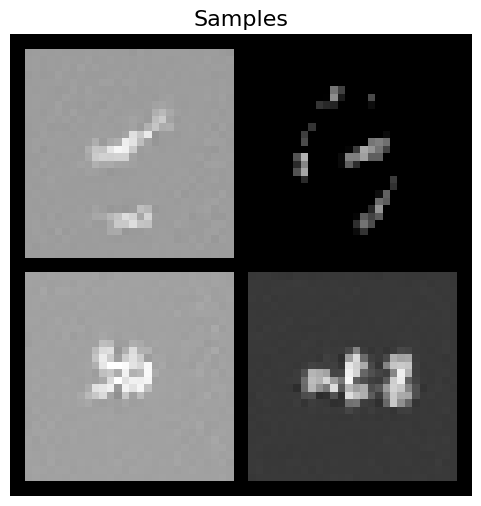

Step 11000/100000.0 Loss: 0.0519
Step 12000/100000.0 Loss: 0.0508


100%|██████████| 1000/1000 [00:06<00:00, 163.19it/s]


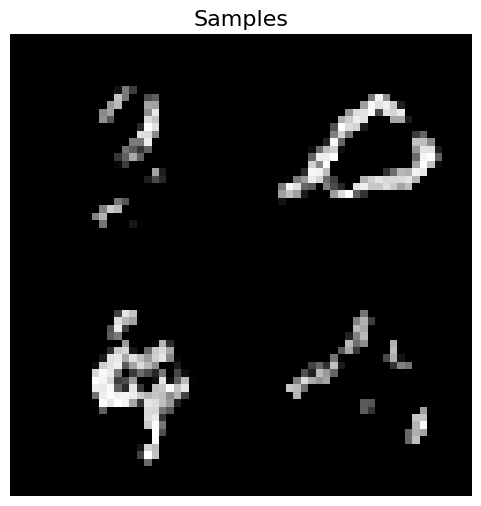

Step 13000/100000.0 Loss: 0.0501
Step 14000/100000.0 Loss: 0.0486


100%|██████████| 1000/1000 [00:06<00:00, 166.33it/s]


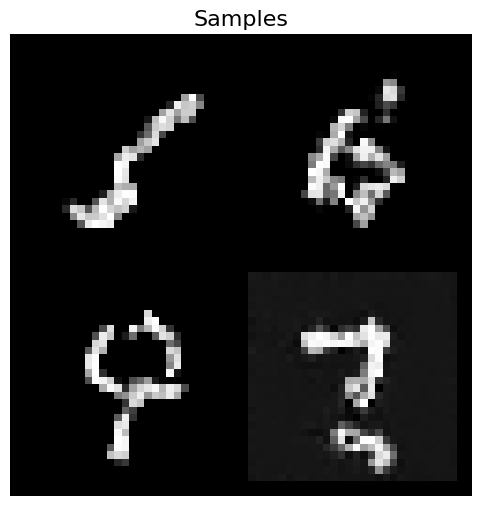

Step 15000/100000.0 Loss: 0.0481
Step 16000/100000.0 Loss: 0.0476


100%|██████████| 1000/1000 [00:05<00:00, 168.19it/s]


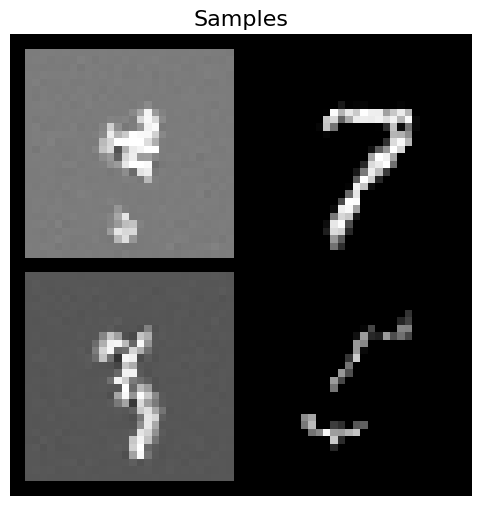

Step 17000/100000.0 Loss: 0.0474
Step 18000/100000.0 Loss: 0.0467


100%|██████████| 1000/1000 [00:05<00:00, 168.55it/s]


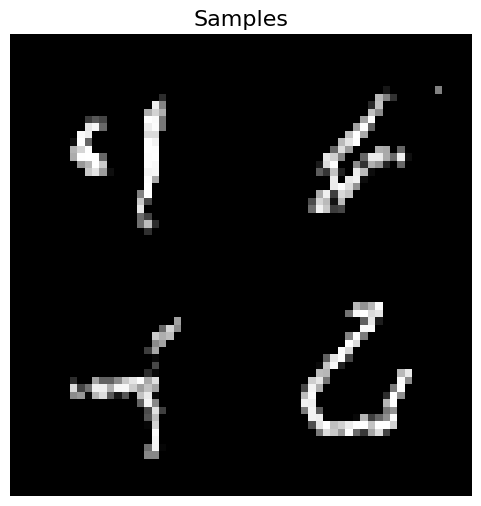

Step 19000/100000.0 Loss: 0.0456
Step 20000/100000.0 Loss: 0.0451


100%|██████████| 1000/1000 [00:05<00:00, 168.57it/s]


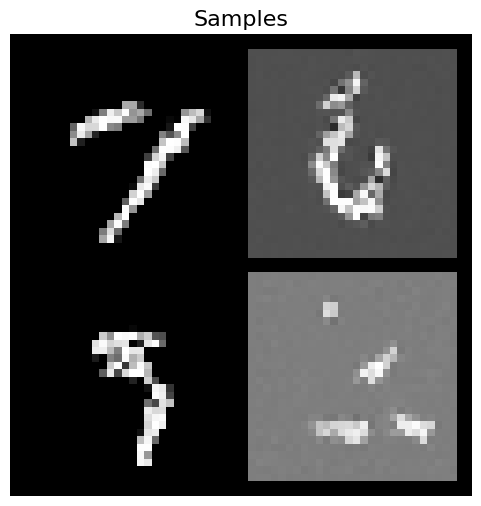

Step 21000/100000.0 Loss: 0.045
Step 22000/100000.0 Loss: 0.0446


100%|██████████| 1000/1000 [00:05<00:00, 169.20it/s]


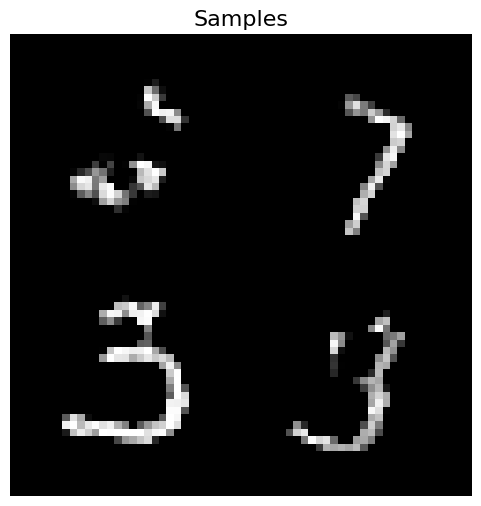

Step 23000/100000.0 Loss: 0.0443
Step 24000/100000.0 Loss: 0.0444


100%|██████████| 1000/1000 [00:05<00:00, 167.88it/s]


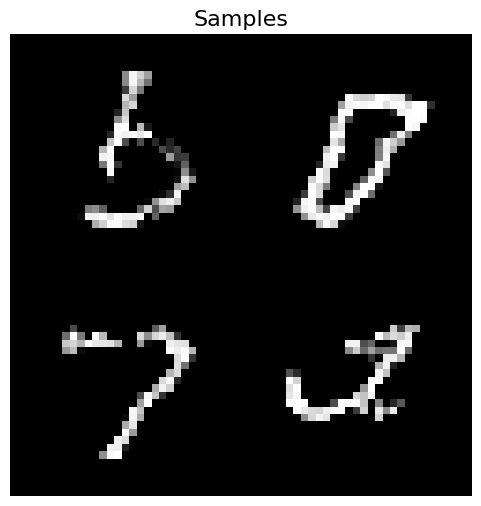

Step 25000/100000.0 Loss: 0.0436
Step 26000/100000.0 Loss: 0.0433


100%|██████████| 1000/1000 [00:05<00:00, 167.78it/s]


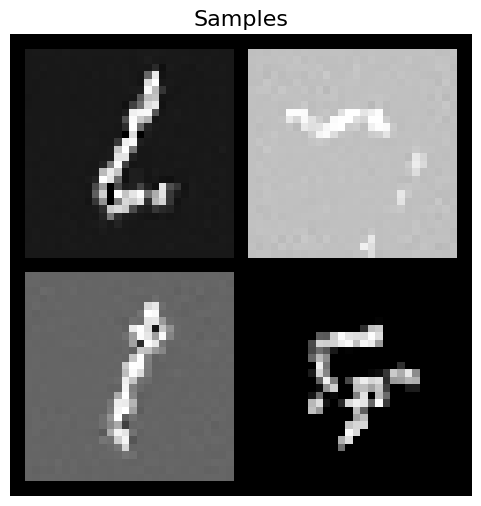

Step 27000/100000.0 Loss: 0.0432
Step 28000/100000.0 Loss: 0.043


100%|██████████| 1000/1000 [00:06<00:00, 165.78it/s]


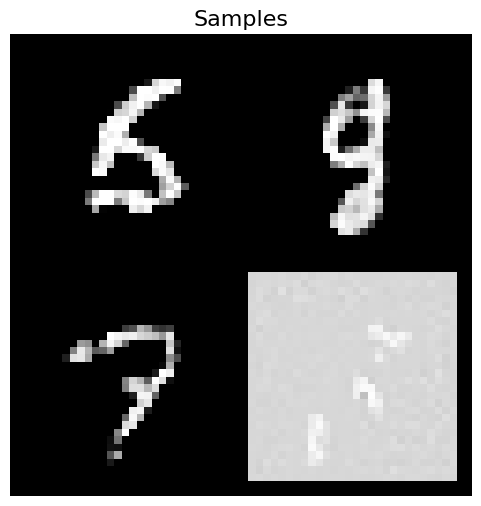

Step 29000/100000.0 Loss: 0.0428
Step 30000/100000.0 Loss: 0.0424


100%|██████████| 1000/1000 [00:05<00:00, 166.85it/s]


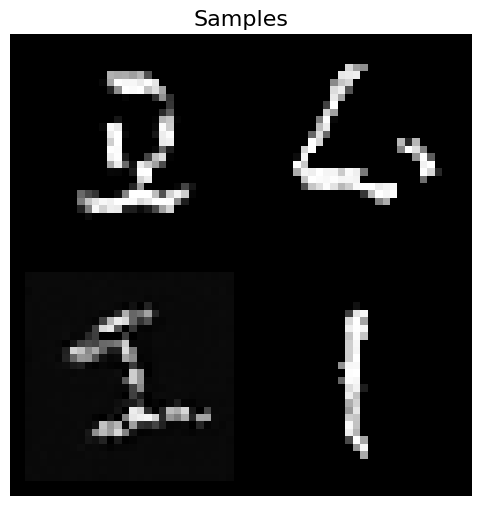

Step 31000/100000.0 Loss: 0.0422
Step 32000/100000.0 Loss: 0.042


100%|██████████| 1000/1000 [00:05<00:00, 167.87it/s]


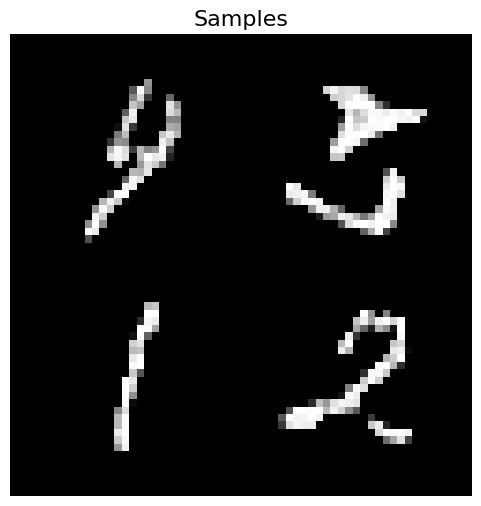

Step 33000/100000.0 Loss: 0.0417
Step 34000/100000.0 Loss: 0.0414


100%|██████████| 1000/1000 [00:06<00:00, 158.09it/s]


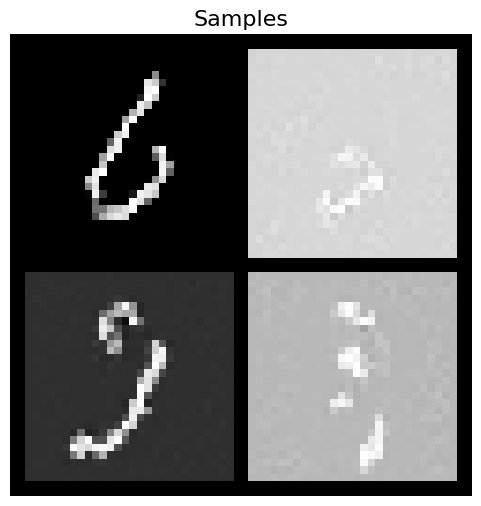

Step 35000/100000.0 Loss: 0.0424
Step 36000/100000.0 Loss: 0.0417


100%|██████████| 1000/1000 [00:06<00:00, 148.36it/s]


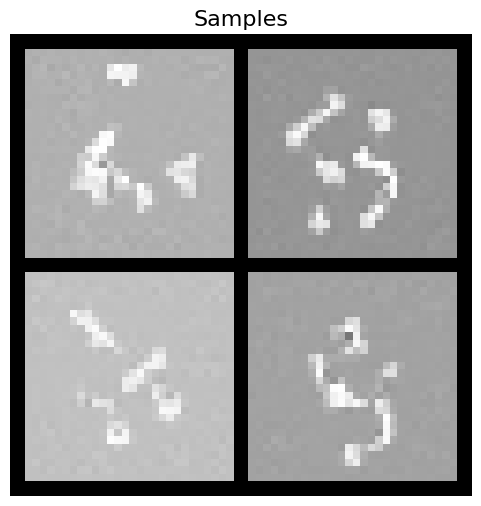

Step 37000/100000.0 Loss: 0.0416
Step 38000/100000.0 Loss: 0.0415


100%|██████████| 1000/1000 [00:06<00:00, 149.68it/s]


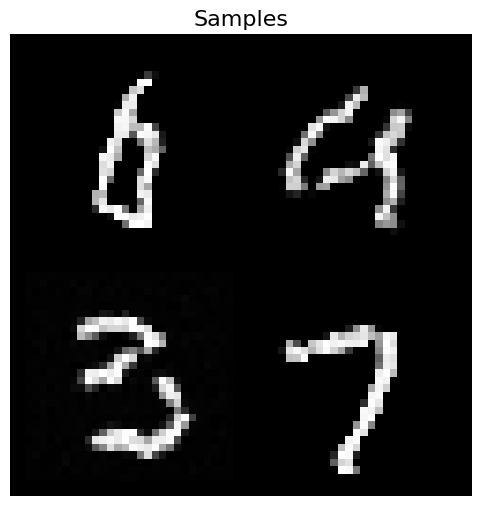

Step 39000/100000.0 Loss: 0.0412
Step 40000/100000.0 Loss: 0.0408


100%|██████████| 1000/1000 [00:06<00:00, 147.38it/s]


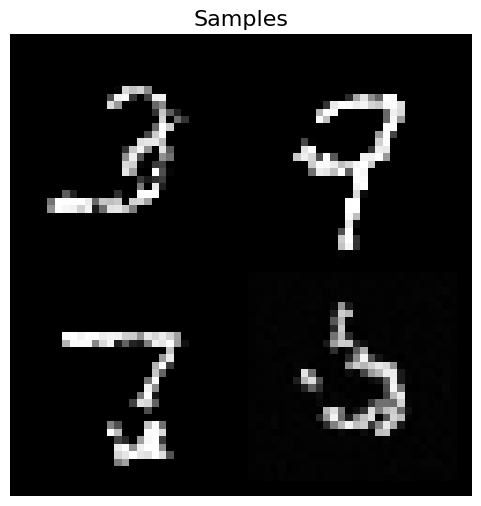

Step 41000/100000.0 Loss: 0.0406
Step 42000/100000.0 Loss: 0.0407


100%|██████████| 1000/1000 [00:06<00:00, 151.77it/s]


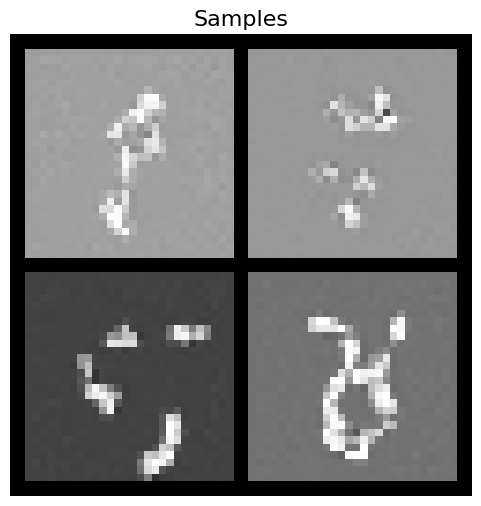

Step 43000/100000.0 Loss: 0.0402
Step 44000/100000.0 Loss: 0.0402


100%|██████████| 1000/1000 [00:06<00:00, 164.91it/s]


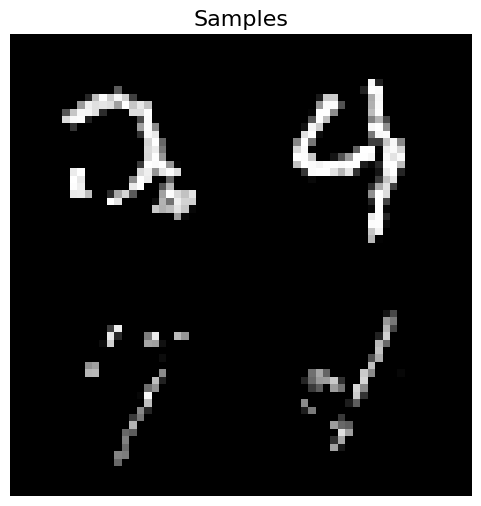

Step 45000/100000.0 Loss: 0.0396
Step 46000/100000.0 Loss: 0.0399


100%|██████████| 1000/1000 [00:06<00:00, 164.14it/s]


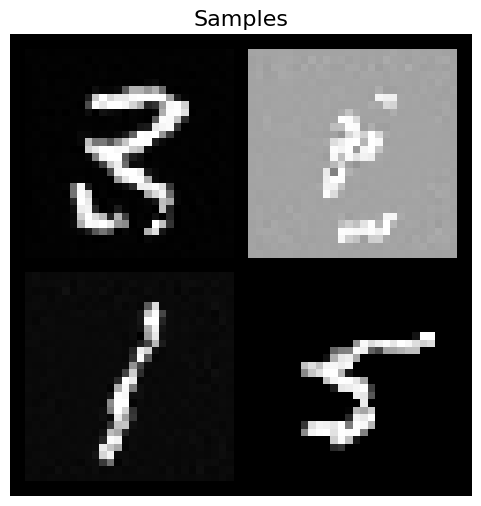

Step 47000/100000.0 Loss: 0.0395
Step 48000/100000.0 Loss: 0.0397


100%|██████████| 1000/1000 [00:06<00:00, 164.88it/s]


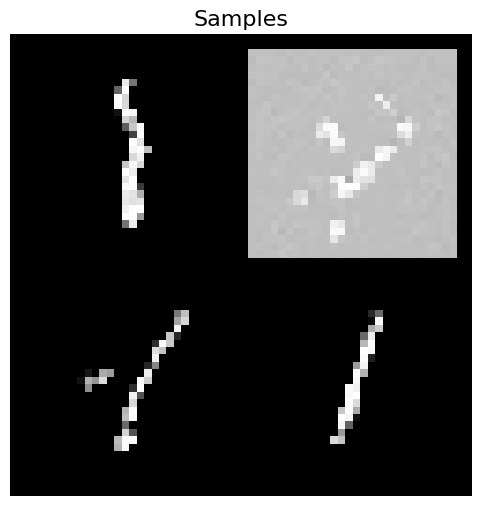

Step 49000/100000.0 Loss: 0.0396
Step 50000/100000.0 Loss: 0.0392


100%|██████████| 1000/1000 [00:06<00:00, 149.83it/s]


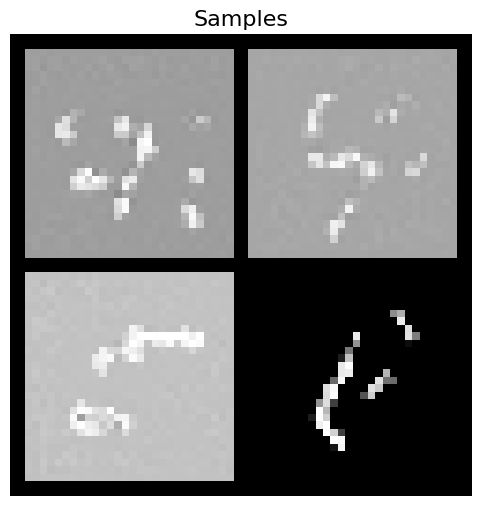

Step 51000/100000.0 Loss: 0.0391
Step 52000/100000.0 Loss: 0.0389


100%|██████████| 1000/1000 [00:06<00:00, 147.53it/s]


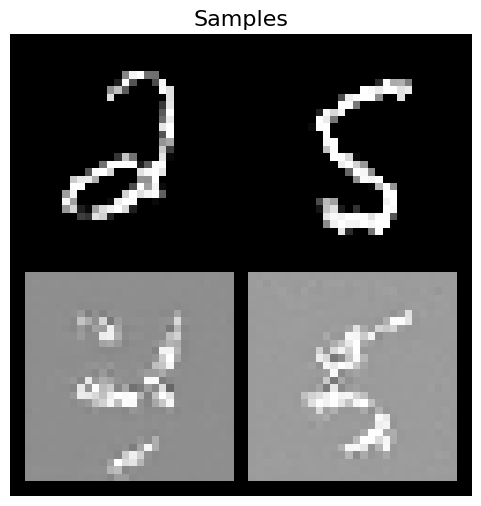

Step 53000/100000.0 Loss: 0.039
Step 54000/100000.0 Loss: 0.039


100%|██████████| 1000/1000 [00:06<00:00, 150.59it/s]


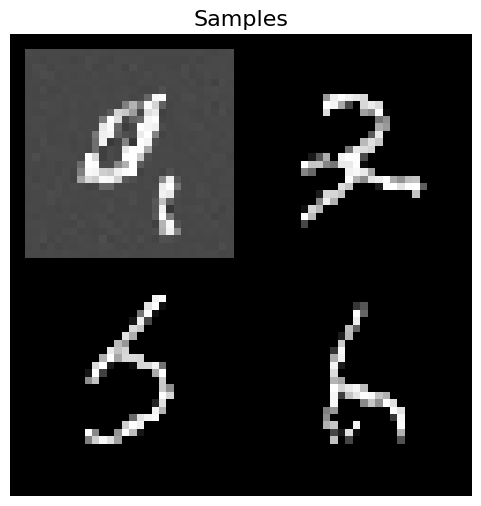

Step 55000/100000.0 Loss: 0.039
Step 56000/100000.0 Loss: 0.0391


100%|██████████| 1000/1000 [00:06<00:00, 147.85it/s]


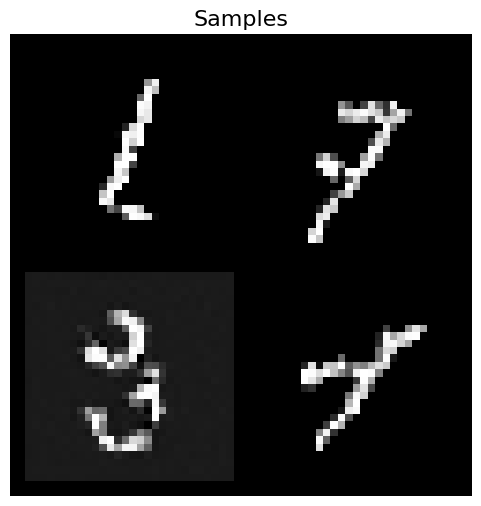

Step 57000/100000.0 Loss: 0.0389
Step 58000/100000.0 Loss: 0.0387


100%|██████████| 1000/1000 [00:06<00:00, 159.52it/s]


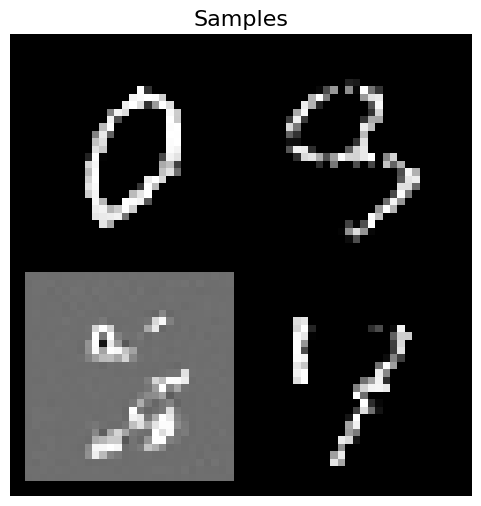

Step 59000/100000.0 Loss: 0.0386
Step 60000/100000.0 Loss: 0.0387


100%|██████████| 1000/1000 [00:06<00:00, 165.43it/s]


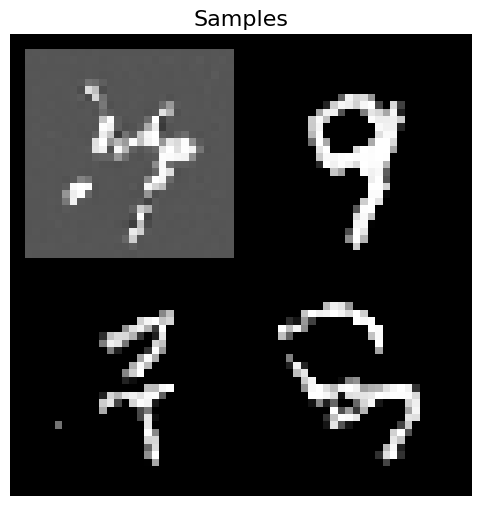

Step 61000/100000.0 Loss: 0.0385
Step 62000/100000.0 Loss: 0.0382


100%|██████████| 1000/1000 [00:06<00:00, 164.20it/s]


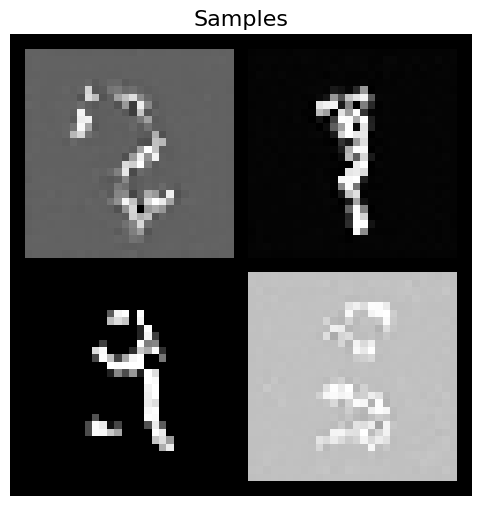

Step 63000/100000.0 Loss: 0.0383
Step 64000/100000.0 Loss: 0.0381


100%|██████████| 1000/1000 [00:06<00:00, 156.73it/s]


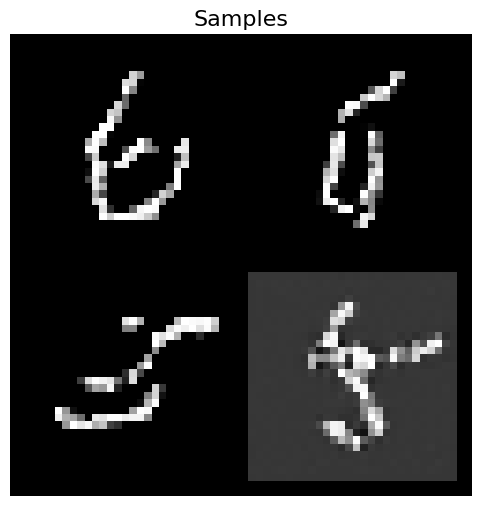

Step 65000/100000.0 Loss: 0.0377
Step 66000/100000.0 Loss: 0.0379


100%|██████████| 1000/1000 [00:06<00:00, 148.26it/s]


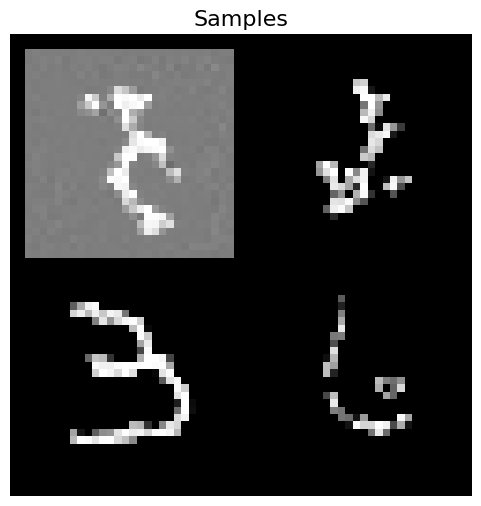

Step 67000/100000.0 Loss: 0.0382
Step 68000/100000.0 Loss: 0.0379


100%|██████████| 1000/1000 [00:06<00:00, 145.22it/s]


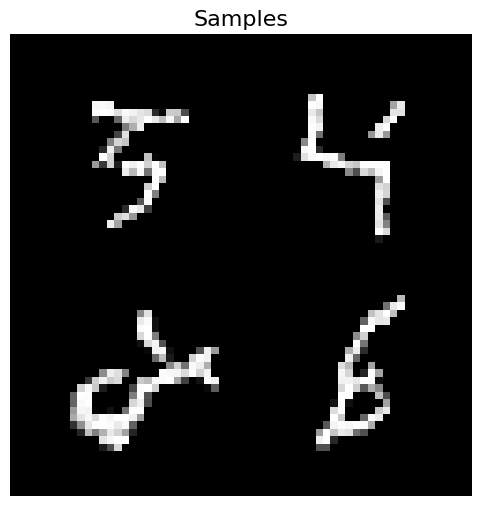

Step 69000/100000.0 Loss: 0.0383
Step 70000/100000.0 Loss: 0.0375


100%|██████████| 1000/1000 [00:06<00:00, 146.92it/s]


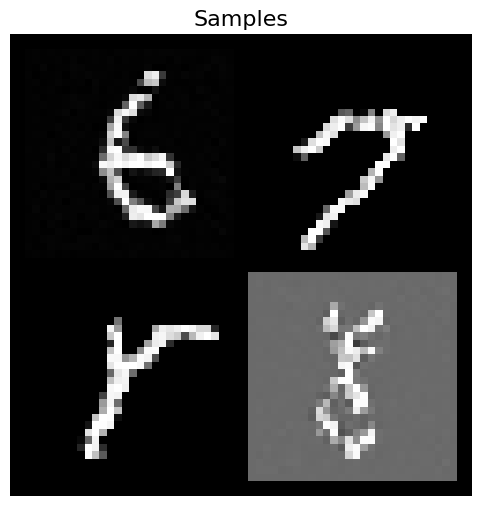

Step 71000/100000.0 Loss: 0.0378
Step 72000/100000.0 Loss: 0.038


100%|██████████| 1000/1000 [00:06<00:00, 150.96it/s]


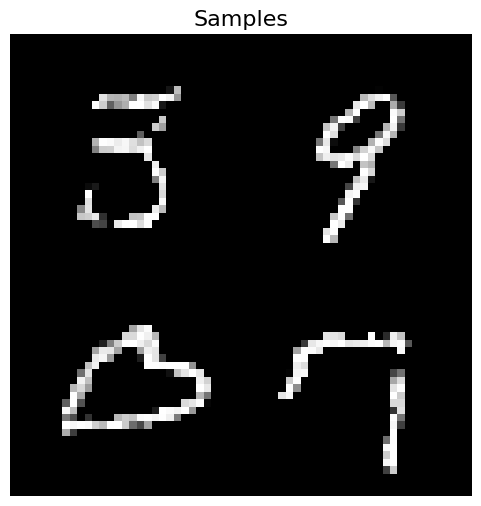

Step 73000/100000.0 Loss: 0.0375
Step 74000/100000.0 Loss: 0.0377


100%|██████████| 1000/1000 [00:06<00:00, 162.17it/s]


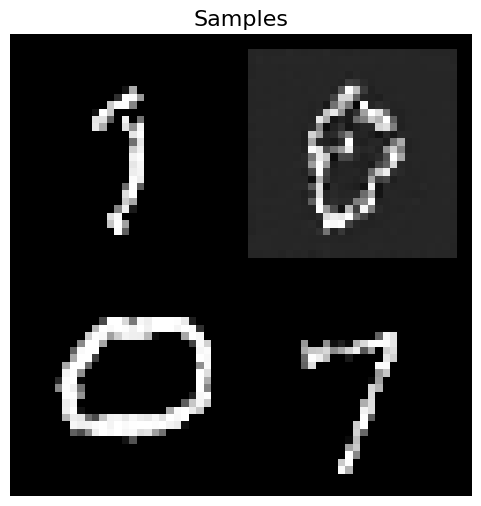

Step 75000/100000.0 Loss: 0.0375
Step 76000/100000.0 Loss: 0.0377


100%|██████████| 1000/1000 [00:06<00:00, 163.25it/s]


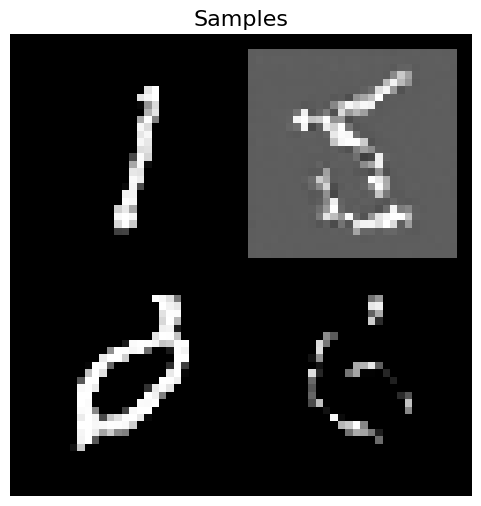

Step 77000/100000.0 Loss: 0.0375
Step 78000/100000.0 Loss: 0.0377


100%|██████████| 1000/1000 [00:06<00:00, 152.90it/s]


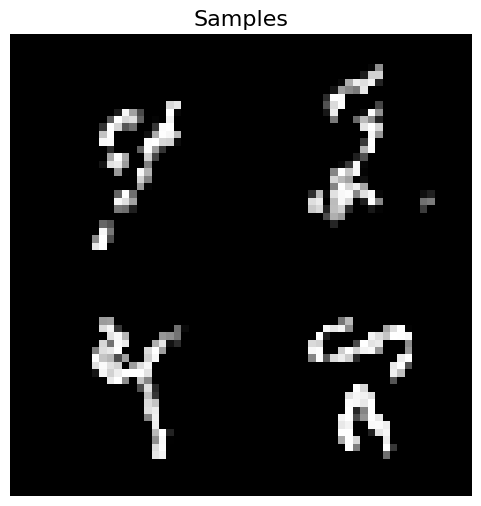

Step 79000/100000.0 Loss: 0.037
Step 80000/100000.0 Loss: 0.0372


100%|██████████| 1000/1000 [00:06<00:00, 145.81it/s]


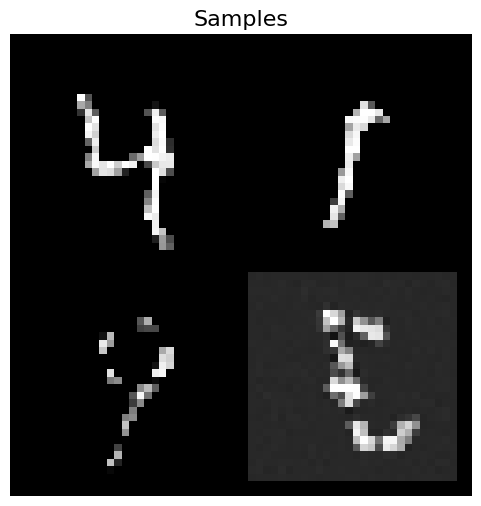

Step 81000/100000.0 Loss: 0.0374
Step 82000/100000.0 Loss: 0.0371


100%|██████████| 1000/1000 [00:06<00:00, 147.18it/s]


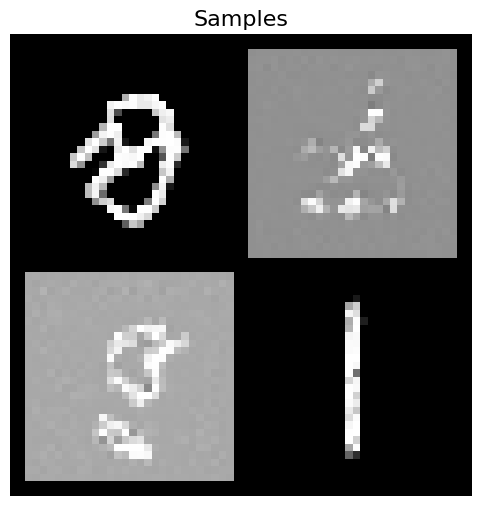

Step 83000/100000.0 Loss: 0.0374
Step 84000/100000.0 Loss: 0.0371


100%|██████████| 1000/1000 [00:06<00:00, 143.39it/s]


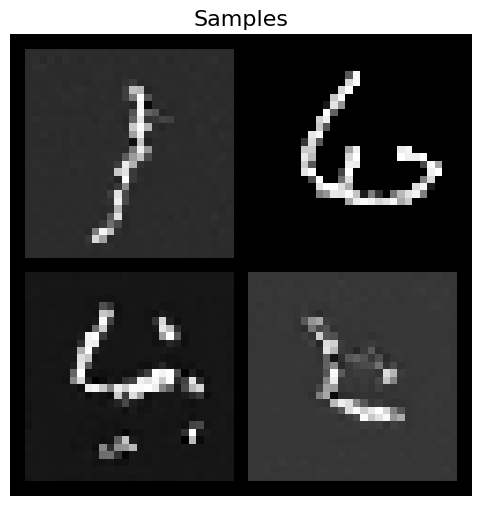

Step 85000/100000.0 Loss: 0.0373
Step 86000/100000.0 Loss: 0.0371


100%|██████████| 1000/1000 [00:06<00:00, 159.62it/s]


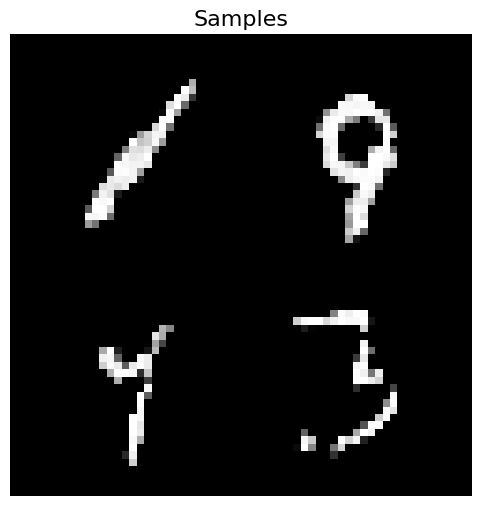

Step 87000/100000.0 Loss: 0.0369
Step 88000/100000.0 Loss: 0.0367


100%|██████████| 1000/1000 [00:06<00:00, 163.53it/s]


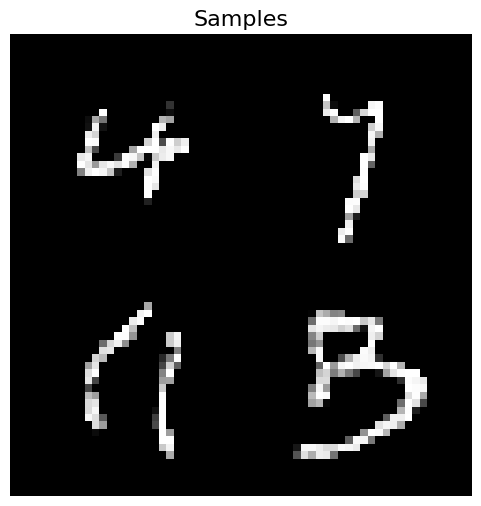

Step 89000/100000.0 Loss: 0.037
Step 90000/100000.0 Loss: 0.0371


100%|██████████| 1000/1000 [00:06<00:00, 158.53it/s]


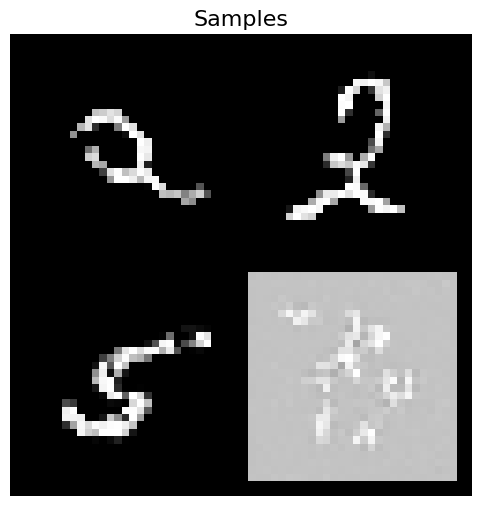

Step 91000/100000.0 Loss: 0.0371
Step 92000/100000.0 Loss: 0.0369


100%|██████████| 1000/1000 [00:06<00:00, 151.60it/s]


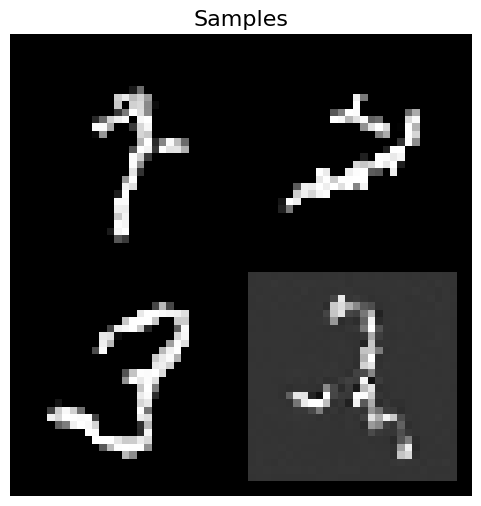

Step 93000/100000.0 Loss: 0.0368
Step 94000/100000.0 Loss: 0.0369


100%|██████████| 1000/1000 [00:06<00:00, 146.39it/s]


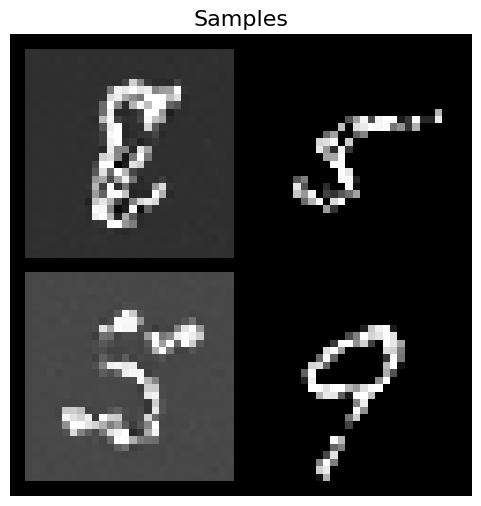

Step 95000/100000.0 Loss: 0.0366
Step 96000/100000.0 Loss: 0.0368


100%|██████████| 1000/1000 [00:06<00:00, 146.81it/s]


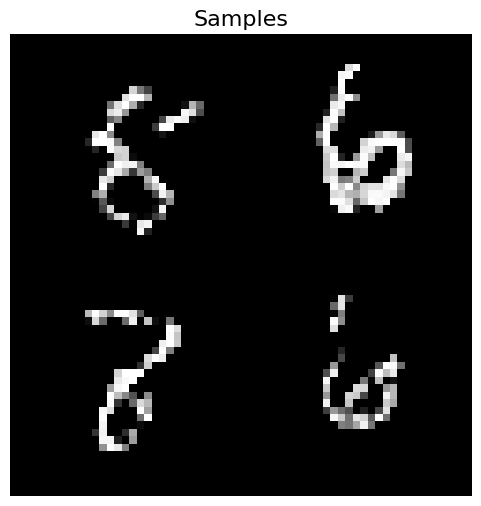

Step 97000/100000.0 Loss: 0.0367
Step 98000/100000.0 Loss: 0.0369


100%|██████████| 1000/1000 [00:07<00:00, 142.64it/s]


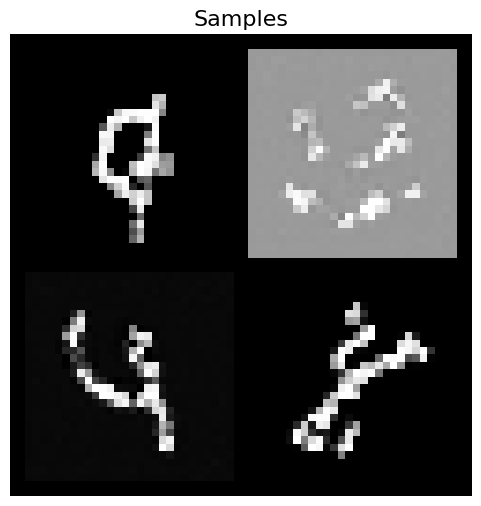

Step 99000/100000.0 Loss: 0.037
Step 100000/100000.0 Loss: 0.0364


100%|██████████| 1000/1000 [00:06<00:00, 161.48it/s]


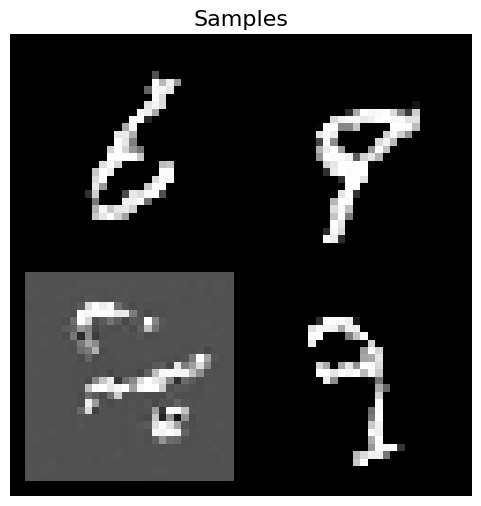

In [93]:
T = 1000
# ====
# your code
# choose these parameters
BATCH_SIZE = 64
LR = 1e-4
WEIGHT_DECAY = 0
STEPS = 1e5
# ====

dataloader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

model_mnist = MyUNet(n_steps=T)
ddpm_mnist = DDPM_mnist(num_timesteps=T, model=model_mnist)

train_model_mnist(
    ddpm=ddpm_mnist,
    dataloader=dataloader,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    steps=STEPS,
    use_cuda=USE_CUDA,
    log_every=1000
)

Let's draw samples from the trained model.

100%|██████████| 1000/1000 [00:06<00:00, 151.23it/s]


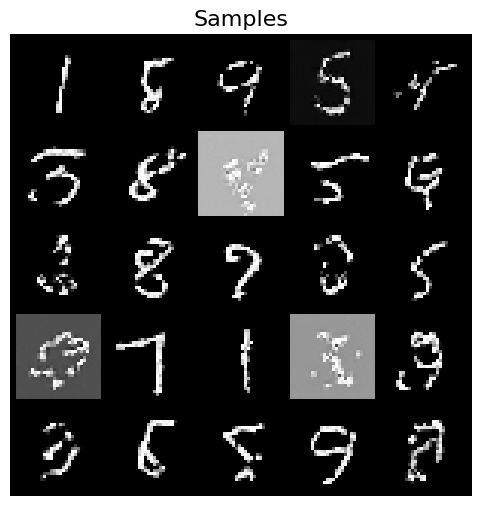

In [95]:
if USE_CUDA:
    ddpm_mnist = ddpm_mnist.cuda()

with torch.no_grad():
    samples = ddpm_mnist.sample(num_samples=25).cpu().numpy()

# samples = samples * DATA_STD + DATA_MEAN


show_samples(samples, title="Samples")